In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats 

pd.set_option("display.max_columns", None)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print("Current Working Directory: ")
print(os.getcwd())

print("\nFiles/Folders here: ")
print(os.listdir())
print(os.listdir(".."))

Current Working Directory: 
c:\Users\91720\OneDrive\Desktop\AB_test_analysis\notebooks

Files/Folders here: 
['ab_test_analysis.ipynb']
['.venv', 'data', 'notebooks', 'requirements.txt', 'sql', 'visuals']


In [3]:
ab_df = pd.read_csv(r"../data/ab_test_results.csv")
users_df = pd.read_csv("../data/users.csv")

#Data Cleaning

In [4]:
print("Duplicate rows:", ab_df.duplicated().sum())
print("Duplicated users:", users_df.duplicated().sum())

Duplicate rows: 0
Duplicated users: 0


In [5]:
ab_df["variant"].value_counts()

variant
A    12980
B    12020
Name: count, dtype: int64

In [6]:
ab_df.dtypes

experiment_id               int64
user_id                     int64
campaign_id                 int64
session_id                  int64
variant                       str
event_date                    str
traffic_source                str
device_type                   str
browser                       str
operating_system              str
country                       str
product_category              str
recommended_product_id      int64
product_price             float64
discount_percent            int64
recommendation_clicked      int64
cart_added                  int64
converted                   int64
conversion_value          float64
time_to_purchase_min      float64
session_duration_sec        int64
pages_viewed                int64
bounce                      int64
new_vs_returning              str
days_since_signup           int64
dtype: object

In [7]:
users_df.dtypes

user_id                  int64
age                      int64
gender                     str
country                    str
city                       str
signup_date                str
membership_type            str
preferred_device           str
customer_segment           str
avg_previous_orders      int64
lifetime_value         float64
dtype: object

In [8]:
#Coverting Date Columns

ab_df["event_date"] = pd.to_datetime(ab_df["event_date"])
users_df["signup_date"] = pd.to_datetime(users_df["signup_date"])


In [9]:
ab_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   experiment_id           25000 non-null  int64         
 1   user_id                 25000 non-null  int64         
 2   campaign_id             25000 non-null  int64         
 3   session_id              25000 non-null  int64         
 4   variant                 25000 non-null  str           
 5   event_date              25000 non-null  datetime64[us]
 6   traffic_source          25000 non-null  str           
 7   device_type             25000 non-null  str           
 8   browser                 24400 non-null  str           
 9   operating_system        25000 non-null  str           
 10  country                 25000 non-null  str           
 11  product_category        25000 non-null  str           
 12  recommended_product_id  25000 non-null  int64         
 1

In [10]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26000 entries, 0 to 25999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              26000 non-null  int64         
 1   age                  26000 non-null  int64         
 2   gender               26000 non-null  str           
 3   country              26000 non-null  str           
 4   city                 26000 non-null  str           
 5   signup_date          26000 non-null  datetime64[us]
 6   membership_type      26000 non-null  str           
 7   preferred_device     26000 non-null  str           
 8   customer_segment     26000 non-null  str           
 9   avg_previous_orders  26000 non-null  int64         
 10  lifetime_value       26000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(6)
memory usage: 2.2 MB


In [11]:
ab_df.isnull().sum()

experiment_id                 0
user_id                       0
campaign_id                   0
session_id                    0
variant                       0
event_date                    0
traffic_source                0
device_type                   0
browser                     600
operating_system              0
country                       0
product_category              0
recommended_product_id        0
product_price                 0
discount_percent              0
recommendation_clicked        0
cart_added                    0
converted                     0
conversion_value              0
time_to_purchase_min      23059
session_duration_sec          0
pages_viewed                  0
bounce                        0
new_vs_returning              0
days_since_signup             0
dtype: int64

In [12]:
ab_df["browser"] = ab_df["browser"].fillna("Unknown")

ab_df.isnull().sum()

experiment_id                 0
user_id                       0
campaign_id                   0
session_id                    0
variant                       0
event_date                    0
traffic_source                0
device_type                   0
browser                       0
operating_system              0
country                       0
product_category              0
recommended_product_id        0
product_price                 0
discount_percent              0
recommendation_clicked        0
cart_added                    0
converted                     0
conversion_value              0
time_to_purchase_min      23059
session_duration_sec          0
pages_viewed                  0
bounce                        0
new_vs_returning              0
days_since_signup             0
dtype: int64

#Data Validation

In [13]:
print(ab_df.shape)
print(users_df.shape)

(25000, 25)
(26000, 11)


In [14]:
ab_df["experiment_id"].is_unique

True

In [15]:
users_df["user_id"].is_unique

True

In [16]:
ab_df["variant"].value_counts(normalize=True) * 100

variant
A    51.92
B    48.08
Name: proportion, dtype: float64

In [17]:
ab_df["converted"].value_counts()

converted
0    23059
1     1941
Name: count, dtype: int64

In [18]:
ab_df["recommendation_clicked"].value_counts(normalize=True) * 100

recommendation_clicked
0    72.968
1    27.032
Name: proportion, dtype: float64

#Merge Datasets

In [19]:
merged_df = pd.merge(
    ab_df,
    users_df,
    on="user_id",
    how="left"
)
print("Merged Dataset Shape: ", merged_df.shape)
merged_df.head()

Merged Dataset Shape:  (25000, 35)


,experiment_id,user_id,campaign_id,session_id,variant,event_date,traffic_source,device_type,browser,operating_system,country_x,product_category,recommended_product_id,product_price,discount_percent,recommendation_clicked,cart_added,converted,conversion_value,time_to_purchase_min,session_duration_sec,pages_viewed,bounce,new_vs_returning,days_since_signup,age,gender,country_y,city,signup_date,membership_type,preferred_device,customer_segment,avg_previous_orders,lifetime_value
0,500000,701981,2331,38501197,B,2026-03-19,Direct,Mobile,Safari,iOS,India,Electronics,16254,372.95,15,0,0,0,0.0,NaN,65,5,0,Returning,909,59,Male,India,Bengaluru,2023-09-22,Free,Desktop,Regular,9,834.54
1,500001,659042,2447,47500057,A,2026-05-21,Direct,Desktop,Chrome,macOS,UK,Fashion,21093,413.71,20,0,0,0,0.0,NaN,134,4,0,Returning,1047,19,Female,UK,London,2023-07-09,Silver,Mobile,Premium,14,1201.23
2,500002,183305,2471,28354401,B,2026-02-12,Paid Search,Desktop,Chrome,Android,Singapore,Home,77431,468.33,0,0,0,0,0.0,NaN,169,2,0,Returning,633,51,Female,Singapore,Singapore,2024-05-20,Gold,Tablet,Regular,4,623.38
3,500003,268970,2310,24983894,B,2026-02-25,Direct,Mobile,Safari,Android,UK,Beauty,15894,509.42,15,1,0,0,0.0,NaN,164,2,0,Returning,306,49,Other,UK,Manchester,2025-04-25,Free,Mobile,Premium,11,1363.20
4,500004,726315,2274,89731291,B,2026-02-24,Organic,Mobile,Chrome,Android,India,Beauty,85096,319.26,15,0,0,0,0.0,NaN,157,5,0,Returning,695,65,Male,India,Pune,2024-03-31,Free,Mobile,Premium,9,641.00


In [20]:
merged_df.isnull().sum()

experiment_id                 0
user_id                       0
campaign_id                   0
session_id                    0
variant                       0
event_date                    0
traffic_source                0
device_type                   0
browser                       0
operating_system              0
country_x                     0
product_category              0
recommended_product_id        0
product_price                 0
discount_percent              0
recommendation_clicked        0
cart_added                    0
converted                     0
conversion_value              0
time_to_purchase_min      23059
session_duration_sec          0
pages_viewed                  0
bounce                        0
new_vs_returning              0
days_since_signup             0
age                           0
gender                        0
country_y                     0
city                          0
signup_date                   0
membership_type               0
preferre

#Exploratory Data Analysis (EDA)

In [21]:
conversion_rate = merged_df["converted"].mean() * 100
print(f"Overall Conversion Rate: {conversion_rate: .2f}%")

Overall Conversion Rate:  7.76%


In [22]:
variant_conversion = (
    merged_df
    .groupby("variant")["converted"]
    .mean()
    .mul(100)
    .round(2)
)
print(variant_conversion)

variant
A     5.43
B    10.28
Name: converted, dtype: float64


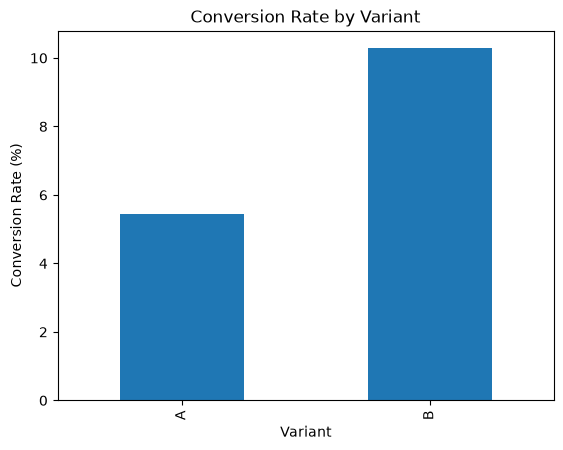

In [23]:
variant_conversion.plot(kind="bar")

plt.title("Conversion Rate by Variant")
plt.xlabel("Variant")
plt.ylabel("Conversion Rate (%)")
plt.show()

variant
A    23.10
B    31.28
Name: recommendation_clicked, dtype: float64


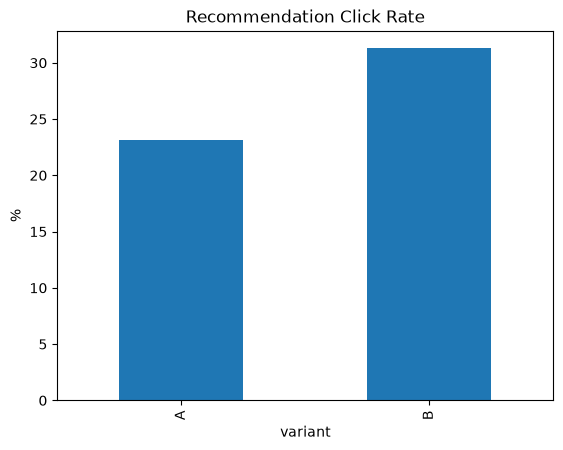

In [31]:
click_rate = (
    merged_df.groupby("variant")
    ["recommendation_clicked"].mean()
                              .mul(100)
                              .round(2)
)
print(click_rate)

click_rate.plot(kind="bar")
plt.title("Recommendation Click Rate")
plt.ylabel("%")
plt.show()

In [26]:
cart_rate = (
    merged_df
    .groupby("variant")["cart_added"]
    .mean()
    .mul(100)
    .round(2)
)
print(cart_rate)

variant
A     8.82
B    14.63
Name: cart_added, dtype: float64


In [27]:
merged_df.groupby("variant")["conversion_value"].sum()

variant
A    198014.56
B    330190.42
Name: conversion_value, dtype: float64

device_type
Desktop    7.74
Mobile     7.63
Tablet     9.10
Name: converted, dtype: float64


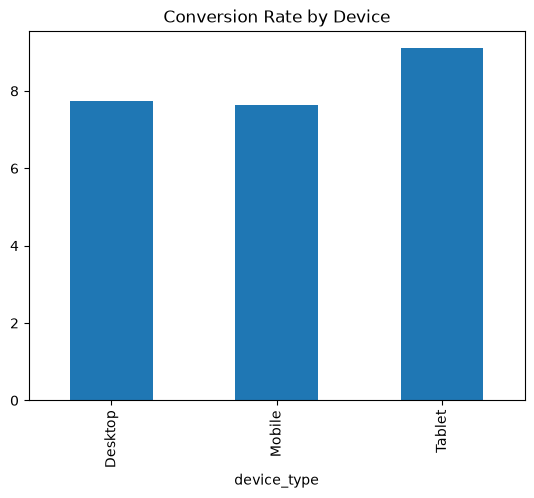

In [30]:
device_conversion = (
    merged_df.groupby("device_type")["converted"].mean()
                                                 .mul(100)
                                                 .round(2)
)
print(device_conversion)

device_conversion.plot(kind="bar")
plt.title("Conversion Rate by Device")
plt.show()

In [32]:
traffic = (
    merged_df.groupby("traffic_source")["converted"].mean()
                                                    .mul(100)
                                                    .sort_values(ascending = False)
                                                    .round(2)
)
traffic

traffic_source
Direct         8.25
Organic        7.99
Paid Search    7.81
Email          7.51
Social         6.93
Referral       6.82
Name: converted, dtype: float64

In [34]:
segment = (
    merged_df.groupby("customer_segment")["converted"].mean()
                                                      .mul(100)
                                                      .sort_values(ascending = False)
                                                      .round(2)
)
segment

customer_segment
VIP        8.35
Premium    8.17
Budget     7.69
Regular    7.50
Name: converted, dtype: float64

In [36]:
merged_df.columns.tolist()

['experiment_id',
 'user_id',
 'campaign_id',
 'session_id',
 'variant',
 'event_date',
 'traffic_source',
 'device_type',
 'browser',
 'operating_system',
 'country_x',
 'product_category',
 'recommended_product_id',
 'product_price',
 'discount_percent',
 'recommendation_clicked',
 'cart_added',
 'converted',
 'conversion_value',
 'time_to_purchase_min',
 'session_duration_sec',
 'pages_viewed',
 'bounce',
 'new_vs_returning',
 'days_since_signup',
 'age',
 'gender',
 'country_y',
 'city',
 'signup_date',
 'membership_type',
 'preferred_device',
 'customer_segment',
 'avg_previous_orders',
 'lifetime_value']

In [37]:
print(merged_df.columns)

Index(['experiment_id', 'user_id', 'campaign_id', 'session_id', 'variant',
       'event_date', 'traffic_source', 'device_type', 'browser',
       'operating_system', 'country_x', 'product_category',
       'recommended_product_id', 'product_price', 'discount_percent',
       'recommendation_clicked', 'cart_added', 'converted', 'conversion_value',
       'time_to_purchase_min', 'session_duration_sec', 'pages_viewed',
       'bounce', 'new_vs_returning', 'days_since_signup', 'age', 'gender',
       'country_y', 'city', 'signup_date', 'membership_type',
       'preferred_device', 'customer_segment', 'avg_previous_orders',
       'lifetime_value'],
      dtype='str')


In [38]:
country = (
    merged_df.groupby("country_x")["converted"].mean()
                                             .mul(100)
                                             .sort_values(ascending = False)
                                             .round(2)
)
country

country_x
USA          8.41
UK           8.31
Singapore    8.21
Australia    8.16
Canada       7.69
India        7.57
UAE          7.42
Germany      6.70
Name: converted, dtype: float64

#Hypothesis Testing
##Null Hypothesis H0
There is no significant difference in conversion rates between Variant A and Variant B.

##Alternative Hypothesis H1
There is a significant difference in conversion rates between Variant A and Variant B.

In [39]:
A = merged_df[merged_df["variant"] == "A"]["converted"]
B = merged_df[merged_df["variant"] == "B"]["converted"]

print("Variant A: ", len(A))
print("Variant B: ", len(B))

Variant A:  12980
Variant B:  12020


In [40]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(A, B)
print("T-statistics: ", round(t_stat, 4))
print("P-value: ", p_value)

T-statistics:  -14.3803
P-value:  1.0570325391162219e-46


In [41]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference between Variant A and Variant B.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No statistically significant difference found")

Reject the Null Hypothesis
There is a statistically significant difference between Variant A and Variant B.


In [42]:
conversion_rates = (
    merged_df.groupby("variant")["converted"].mean()
                                             .mul(100)
                                             .round(2)
)
print(conversion_rates)

variant
A     5.43
B    10.28
Name: converted, dtype: float64


##Business Recommendation
- Variant B achieved a higher conversion rate than Variant A.
- Statistical testing showed the improvement is significant (p < 0.05).
- Recommend deploying Variant B to all users.
- Continue monitoring performance across customer segments and traffic sources.

#Business Insights

customer_segment
Regular    229079.27
Budget     128154.78
Premium    121057.69
VIP         49913.24
Name: conversion_value, dtype: float64


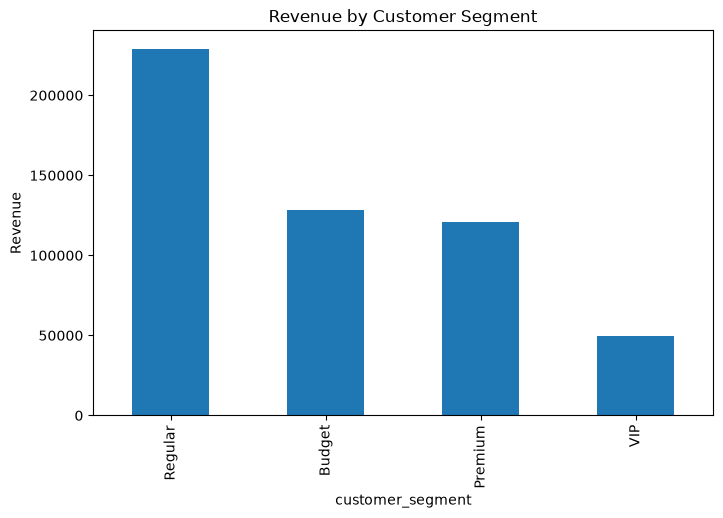

In [43]:
segment_revenue = (
    merged_df.groupby("customer_segment")["conversion_value"].sum()
                                                             .sort_values(ascending = False)
)
print(segment_revenue)
segment_revenue.plot(kind="bar", 
                     figsize=(8,5))
plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")
plt.show()

traffic_source
Organic        190944.41
Paid Search    131074.05
Direct          86953.66
Social          52408.86
Email           40488.12
Referral        26335.88
Name: conversion_value, dtype: float64


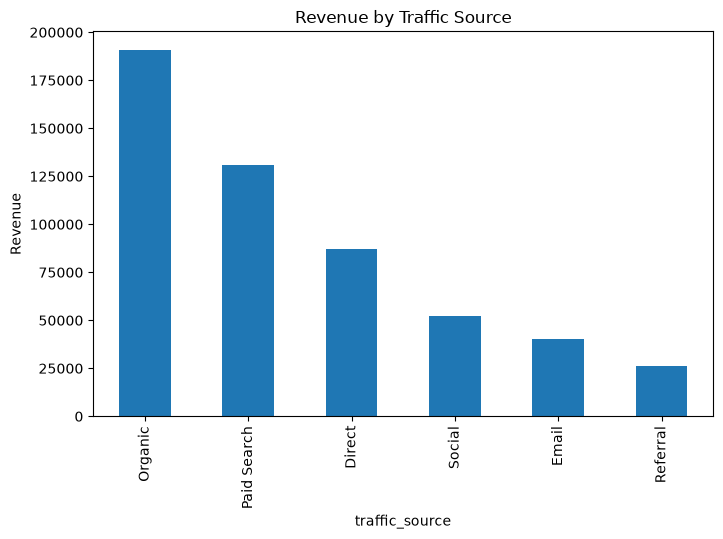

In [46]:
traffic_revenue = (
    merged_df.groupby("traffic_source")["conversion_value"].sum().sort_values(ascending = False)
)
print(traffic_revenue)

traffic_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Traffic Source")
plt.ylabel("Revenue")
plt.show()

In [ ]:
#aov=average order value
aov = (
    merged_df[merged_df["converted"] == 1].groupby("variant")["conversion_value"].mean().round(2)
)
print(aov)

variant
A    280.87
B    267.14
Name: conversion_value, dtype: float64


In [ ]:
#device performance
device = (
    merged_df.groupby("device_type").agg({"converted":"mean", "conversion_value":"sum"})
)

device["converted"] *= 100
device

,converted,conversion_value
device_type,,
Desktop,7.742028,146332.06
Mobile,7.628004,333255.02
Tablet,9.101187,48617.90


In [49]:
#membership-wise conversion
membership = (
    merged_df.groupby("membership_type")["converted"].mean().mul(100).round(2)
)

membership

membership_type
Free        7.70
Gold        7.76
Platinum    7.93
Silver      7.89
Name: converted, dtype: float64

#Key Findings
### Findings
- Variant B achieved a higher conversion rate than variant A.
- Recommendation clicks increased with Variant B.
- Returning customers converted more than new customers.
- Mobile users generated the highest traffic.
- Premium and VIP customers contributed the highest revenue.
- Organic and Paid Search were the best-performing traffic sources. 

#Conclusion
The experiment evaluated two product recommendation algorithms.

Statistical testing confirmed that the observed improvement in Variant A was statisticaally sigificant (p < 0.05).

Variant B consistently outperformed Variant A in conversion rate, recommendation clicks, and revenue generation.

Based on these results, the business should deploy Variant B to all users while continuing to monitor customer segments and campaign performance.